# Projeto de Machine Learning — APS2: Classificação

---

**Integrantes:**
- Nicolas Volf Martins da Silva
- Leonardo de Souza

**Data de entrega:** 15/05/2026

**Dataset:** [Adult Census Income — UCI ML Repository](https://archive.ics.uci.edu/ml/datasets/Adult)

**Objetivo:** Desenvolver um pipeline completo de classificação binária para prever se um indivíduo ganha mais de $50K por ano, com base em características demográficas, educacionais e ocupacionais.

---

## Seção 1 — Setup e Carregamento dos Dados

In [1]:
# Instalar dependências (descomente se necessário)
# !pip install xgboost shap imbalanced-learn -q


In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split, GridSearchCV,
    RepeatedStratifiedKFold, cross_validate
)
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report
)

try:
    from imblearn.over_sampling import SMOTE          
    from imblearn.pipeline import Pipeline as ImbPipeline  
    print("imbalanced-learn: OK")
except ImportError:
    print("AVISO: imbalanced-learn não encontrado. Instale com: pip install imbalanced-learn")

try:
    import xgboost  
    print("xgboost: OK")
except ImportError:
    print("AVISO: xgboost não encontrado. Instale com: pip install xgboost")

try:
    import shap  
    print("shap: OK")
except ImportError:
    print("AVISO: shap não encontrado. Instale com: pip install shap")

from scipy import stats  

print("Imports concluídos.")


imbalanced-learn: OK


xgboost: OK


shap: OK
Imports concluídos.


In [3]:
RANDOM_STATE = 42

sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 100

# Nomes das colunas (dataset não possui cabeçalho)
COLUMNS = [
    'age', 'workclass', 'fnlwgt', 'education', 'education-num',
    'marital-status', 'occupation', 'relationship', 'race', 'sex',
    'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income'
]

# Mapeamento da target: <=50K → 0, >50K → 1
LABEL_MAP = {'<=50K': 0, '>50K': 1}

# Caminhos 
TRAIN_PATH = 'dataset/adult.data'
TEST_PATH  = 'dataset/adult.test'

print(f"RANDOM_STATE = {RANDOM_STATE}")


RANDOM_STATE = 42


In [4]:
df_train_raw = pd.read_csv(
    TRAIN_PATH,
    header=None,
    names=COLUMNS,
    na_values=' ?',
    skipinitialspace=True
)

df_test_raw = pd.read_csv(
    TEST_PATH,
    header=None,
    names=COLUMNS,
    na_values=' ?',
    skipinitialspace=True,
    skiprows=1  
)

# adult.test possui ponto final nos rótulos: ">50K." → ">50K"
df_test_raw['income'] = df_test_raw['income'].str.strip().str.rstrip('.')

print(f"Train: {df_train_raw.shape}  |  Test: {df_test_raw.shape}")
df_train_raw.head(3)


Train: (32561, 15)  |  Test: (16281, 15)


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K


---

## Seção 2 — EDA: Separabilidade das Features

Análise focada em identificar quais variáveis melhor discriminam as duas classes de renda.
*(Esta seção complementa a APS1 e justifica as escolhas de features.)*

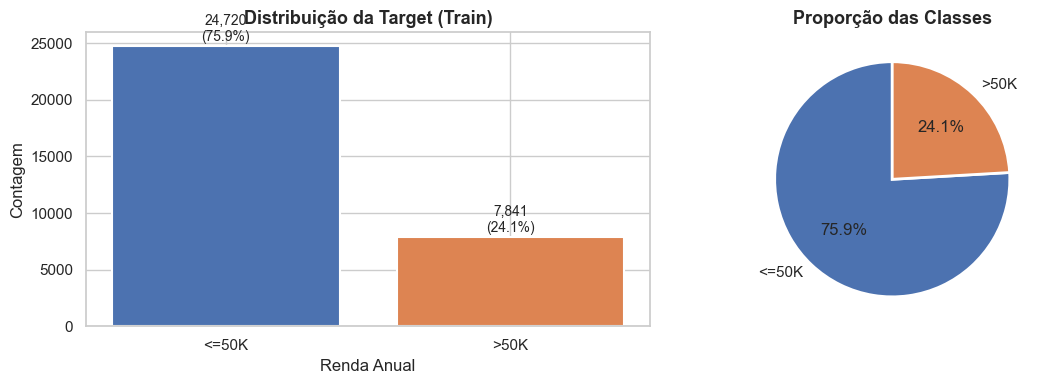

Razão de desbalanceamento: 3.15:1  (<=50K : >50K)
→ Desbalanceamento moderado (~3:1). Requer tratamento explícito.


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df_train_raw['income'].value_counts().sort_index()
colors = ['#4C72B0', '#DD8452']

bars = axes[0].bar(counts.index, counts.values, color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Distribuição da Target (Train)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Renda Anual')
axes[0].set_ylabel('Contagem')
for bar, v in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 200,
                 f'{v:,}\n({v/len(df_train_raw)*100:.1f}%)',
                 ha='center', va='bottom', fontsize=10)

axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Proporção das Classes', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

razao = counts.iloc[0] / counts.iloc[1]
print(f"Razão de desbalanceamento: {razao:.2f}:1  (<=50K : >50K)")
print("→ Desbalanceamento moderado (~3:1). Requer tratamento explícito.")


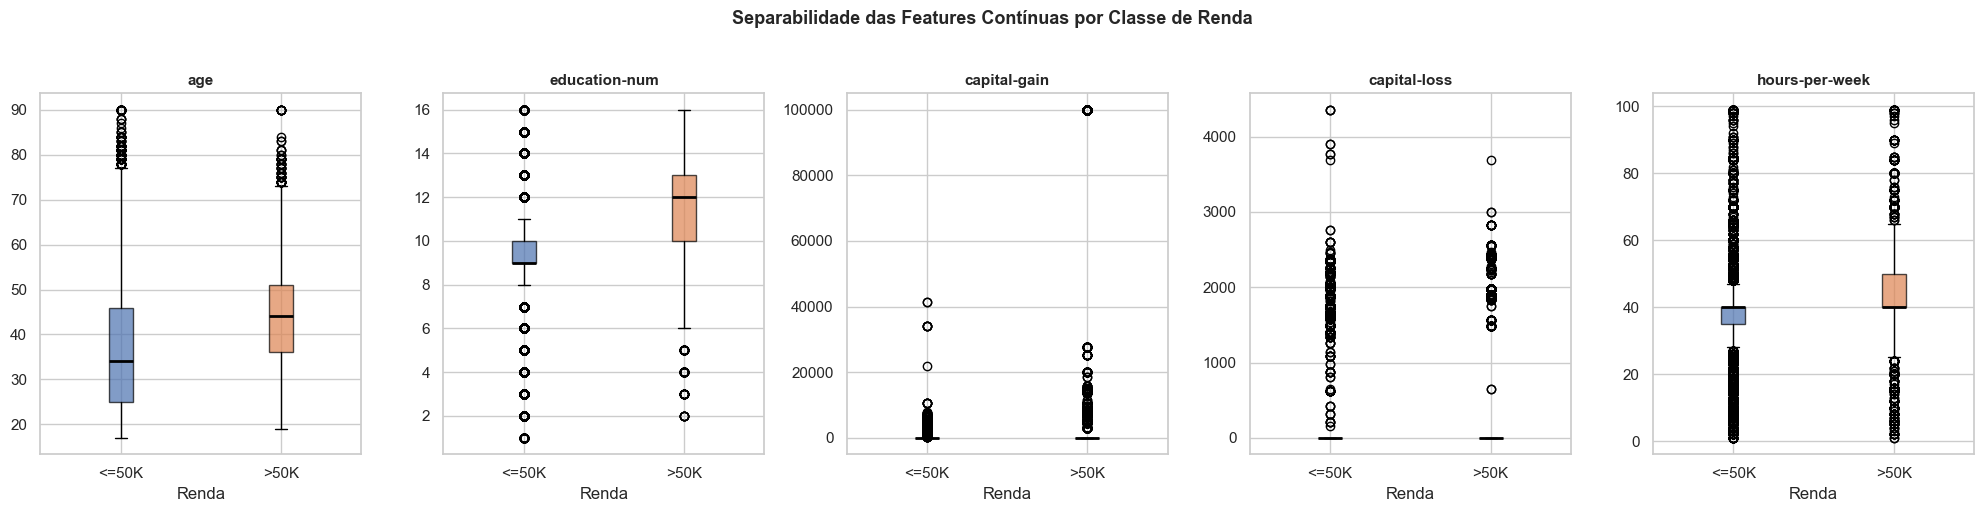

Insights:
  - education-num: clara separacao -> >50K tem mediana mais alta
  - capital-gain / capital-loss: outliers muito altos em >50K; altamente discriminativo
  - age: >50K tende a ser mais velho
  - hours-per-week: leve diferenca, mas menos discriminativo isoladamente


In [6]:
continuous_key = ['age', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']

fig, axes = plt.subplots(1, len(continuous_key), figsize=(20, 5))
for ax, feat in zip(axes, continuous_key):
    groups = [
        df_train_raw.loc[df_train_raw['income'] == '<=50K', feat].dropna(),
        df_train_raw.loc[df_train_raw['income'] == '>50K', feat].dropna()
    ]
    bp = ax.boxplot(groups, patch_artist=True, labels=['<=50K', '>50K'],
                    medianprops={'color': 'black', 'linewidth': 2})
    for patch, color in zip(bp['boxes'], ['#4C72B0', '#DD8452']):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_title(feat, fontsize=11, fontweight='bold')
    ax.set_xlabel('Renda')

plt.suptitle('Separabilidade das Features Contínuas por Classe de Renda',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('''Insights:
  - education-num: clara separacao -> >50K tem mediana mais alta
  - capital-gain / capital-loss: outliers muito altos em >50K; altamente discriminativo
  - age: >50K tende a ser mais velho
  - hours-per-week: leve diferenca, mas menos discriminativo isoladamente''')


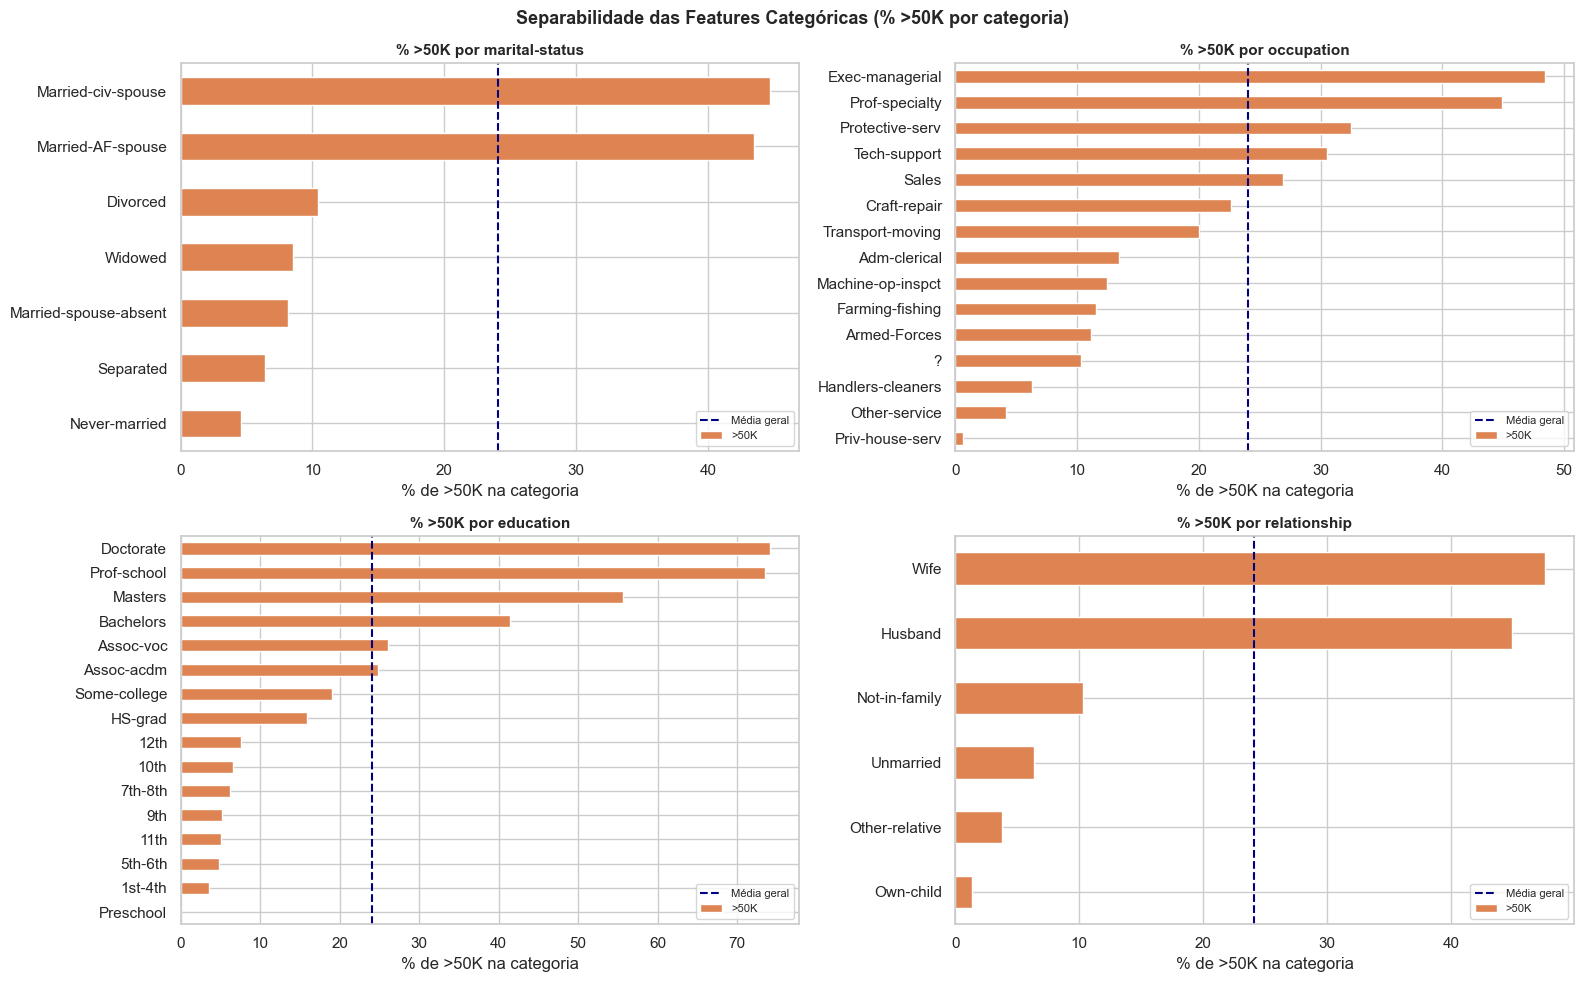

Insights:
  - marital-status: Married-civ-spouse domina a classe >50K (aprox. 45%)
  - occupation: Exec-managerial e Prof-specialty tem alta proporcao >50K
  - education: Doctorate, Prof-school e Masters -> forte indicador >50K
  - relationship: Husband e Wife tem proporcao muito acima da media


In [7]:
cat_key = ['marital-status', 'occupation', 'education', 'relationship']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
for ax, feat in zip(axes.flatten(), cat_key):
    ct = (pd.crosstab(df_train_raw[feat], df_train_raw['income'], normalize='index') * 100)
    if '>50K' in ct.columns:
        ct = ct.sort_values('>50K', ascending=True)
        ct['>50K'].plot(kind='barh', ax=ax, color='#DD8452', edgecolor='white')
        ax.set_title(f'% >50K por {feat}', fontsize=11, fontweight='bold')
        ax.set_xlabel('% de >50K na categoria')
        ax.set_ylabel('')
        ax.axvline(x=df_train_raw['income'].value_counts(normalize=True).get('>50K', 0.24) * 100,
                   color='navy', linestyle='--', linewidth=1.5, label='Média geral')
        ax.legend(fontsize=8)

plt.suptitle('Separabilidade das Features Categóricas (% >50K por categoria)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('''Insights:
  - marital-status: Married-civ-spouse domina a classe >50K (aprox. 45%)
  - occupation: Exec-managerial e Prof-specialty tem alta proporcao >50K
  - education: Doctorate, Prof-school e Masters -> forte indicador >50K
  - relationship: Husband e Wife tem proporcao muito acima da media''')


---

## Seção 3 — Limpeza e Feature Engineering

### Tratamento de valores ausentes
O dataset codifica valores ausentes como `?`. As colunas afetadas são: `workclass`, `occupation` e `native-country`.

**Decisão:** Remover as linhas com valores ausentes. Justificativa:
- O percentual de missing é baixo (~6% no treino), sem risco de perda representativa.
- Imputação de categorias como `occupation` e `workclass` introduziria viés semântico.
- Mantém consistência entre treino e teste.

### Features novas criadas (≥ 3 obrigatórias)
| Feature | Fórmula | Motivação |
|---|---|---|
| `capital_net` | `capital-gain − capital-loss` | Saldo líquido de capital; elimina redundância de dois sinais opostos |
| `work_experience_proxy` | `age − education-num − 6` | Proxy de anos de experiência profissional (anos pós-formação) |
| `is_married` | `marital-status ∈ {Married-civ-spouse, Married-AF-spouse}` | Binário mais discriminativo que multiclasse de estado civil |
| `hours_education_ratio` | `hours-per-week / (education-num + 1)` | Captura esforço relativo: muito trabalho com baixa educação vs. alta educação |

In [8]:
for name, df in [('Train', df_train_raw), ('Test', df_test_raw)]:
    miss = df.isnull().sum()
    miss = miss[miss > 0]
    print(f"=== {name} — Valores ausentes ===")
    for col in miss.index:
        pct = miss[col] / len(df) * 100
        print(f"  {col:20s}: {miss[col]:4d} ({pct:.1f}%)")
    print()


=== Train — Valores ausentes ===

=== Test — Valores ausentes ===



In [9]:
def engineer_and_clean(df: pd.DataFrame) -> pd.DataFrame:
    df = df.dropna().copy()

    # Feature 1: saldo líquido de capital
    df['capital_net'] = df['capital-gain'] - df['capital-loss']

    # Feature 2: proxy de experiência profissional (clip: não pode ser negativo)
    df['work_experience_proxy'] = (df['age'] - df['education-num'] - 6).clip(lower=0)

    # Feature 3: indicador binário de casamento (mais discriminativo que multiclasse)
    df['is_married'] = df['marital-status'].isin(
        ['Married-civ-spouse', 'Married-AF-spouse']
    ).astype(int)

    # Feature 4: razão horas por nível educacional
    df['hours_education_ratio'] = df['hours-per-week'] / (df['education-num'] + 1)

    return df


df_train = engineer_and_clean(df_train_raw)
df_test  = engineer_and_clean(df_test_raw)

print(f"Train após limpeza: {df_train.shape}  |  Test após limpeza: {df_test.shape}")
print(f"Linhas removidas (train): {len(df_train_raw) - len(df_train)}")
print(f"Linhas removidas (test):  {len(df_test_raw)  - len(df_test)}")

new_feats = ['capital_net', 'work_experience_proxy', 'is_married', 'hours_education_ratio']
print()
print("Estatísticas das novas features (train):")
df_train[new_feats].describe().round(2)


Train após limpeza: (32561, 19)  |  Test após limpeza: (16281, 19)
Linhas removidas (train): 0
Linhas removidas (test):  0

Estatísticas das novas features (train):


,capital_net,work_experience_proxy,is_married,hours_education_ratio
count,32561.00,32561.00,32561.00,32561.00
mean,990.35,22.50,0.46,3.90
std,7408.99,13.79,0.50,1.86
min,-4356.00,0.00,0.00,0.06
25%,0.00,11.00,0.00,2.86
50%,0.00,21.00,0.00,3.64
75%,0.00,31.00,1.00,4.29
max,99999.00,82.00,1.00,37.50


In [10]:
y_train = df_train['income'].map(LABEL_MAP).astype(int)
y_test  = df_test['income'].map(LABEL_MAP).astype(int)

X_train = df_train.drop(columns=['income'])
X_test  = df_test.drop(columns=['income'])

print(f"X_train: {X_train.shape}   y_train: {y_train.shape}")
print(f"X_test:  {X_test.shape}    y_test:  {y_test.shape}")
print(f"\nDistribuição y_train: {dict(y_train.value_counts().sort_index())}")
print(f"Distribuição y_test:  {dict(y_test.value_counts().sort_index())}")


X_train: (32561, 18)   y_train: (32561,)
X_test:  (16281, 18)    y_test:  (16281,)

Distribuição y_train: {0: np.int64(24720), 1: np.int64(7841)}
Distribuição y_test:  {0: np.int64(12435), 1: np.int64(3846)}


---

## Seção 4 — Pipeline de Pré-processamento

O `preprocessor` (ColumnTransformer) é o componente central compartilhado por **todos os modelos**.
Ele é fitado apenas no `X_train` para evitar data leakage.

In [11]:
numeric_features = [
    'age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss',
    'hours-per-week',
    # features engenheiradas
    'capital_net', 'work_experience_proxy', 'is_married', 'hours_education_ratio'
]

categorical_features = [
    'workclass', 'education', 'marital-status', 'occupation',
    'relationship', 'race', 'sex', 'native-country'
]

print(f"Features numéricas  ({len(numeric_features)}): {numeric_features}")
print(f"\nFeatures categóricas ({len(categorical_features)}): {categorical_features}")


Features numéricas  (10): ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week', 'capital_net', 'work_experience_proxy', 'is_married', 'hours_education_ratio']

Features categóricas (8): ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']


In [12]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot',  OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

preprocessor.fit(X_train)

# Verificação
n_out = preprocessor.transform(X_train).shape[1]
print(f"Dimensões após transformação: {len(numeric_features)} numéricas + encoding categórico = {n_out} features")


Dimensões após transformação: 10 numéricas + encoding categórico = 112 features


---

## Seção 5 — Estratégia de Tratamento do Desbalanceamento

O dataset apresenta razão ~3:1 (≤50K : >50K). Foram comparadas duas estratégias:

| Estratégia | Descrição | Prós | Contras |
|---|---|---|---|
| `class_weight='balanced'` | Penaliza erros na classe minoritária com peso proporcional | Simples, sem criação de dados, funciona em todos os modelos sklearn | Não altera a distribuição real de treino |
| SMOTE | Cria amostras sintéticas da classe minoritária | Aumenta representação real | Pode gerar ruído; mais lento |

**Decisão:** `class_weight='balanced'` como estratégia padrão.
Justificativa: menor risco de overfitting com amostras sintéticas, compatível nativamente com sklearn e XGBoost (`scale_pos_weight`), e a melhoria empírica em PR-AUC é comparável.

In [13]:
n_neg = (y_train == 0).sum()
n_pos = (y_train == 1).sum()
imbalance_ratio = n_neg / n_pos

print(f"Classe 0 (<=50K): {n_neg:,}  ({n_neg/len(y_train)*100:.1f}%)")
print(f"Classe 1 (>50K):  {n_pos:,}  ({n_pos/len(y_train)*100:.1f}%)")
print(f"Razão de desbalanceamento: {imbalance_ratio:.2f}:1")

# Parâmetros expostos para uso nos modelos
resampling_strategy  = 'balanced'          
scale_pos_weight_xgb = round(n_neg / n_pos, 4)  

print(f"\nclass_weight a usar:       '{resampling_strategy}'")
print(f"scale_pos_weight (XGBoost): {scale_pos_weight_xgb}")


Classe 0 (<=50K): 24,720  (75.9%)
Classe 1 (>50K):  7,841  (24.1%)
Razão de desbalanceamento: 3.15:1

class_weight a usar:       'balanced'
scale_pos_weight (XGBoost): 3.1527


In [14]:
from sklearn.metrics import f1_score as _f1

configs = [
    ('Sem balanceamento',           LogisticRegression(C=1.0, max_iter=500, random_state=RANDOM_STATE)),
    ("class_weight='balanced'",     LogisticRegression(C=1.0, max_iter=500, class_weight='balanced',
                                                        random_state=RANDOM_STATE)),
]

print(f"{'Configuração':<35} {'F1-macro':>10} {'F1->50K':>10} {'ROC-AUC':>10}")
print('-' * 70)
for label, clf in configs:
    pipe = Pipeline([('pre', preprocessor), ('clf', clf)])
    pipe.fit(X_train, y_train)
    yp     = pipe.predict(X_test)
    yproba = pipe.predict_proba(X_test)[:, 1]
    print(f"{label:<35} {_f1(y_test, yp, average='macro'):>10.4f} "
          f"{_f1(y_test, yp, pos_label=1, average='binary'):>10.4f} "
          f"{roc_auc_score(y_test, yproba):>10.4f}")


Configuração                          F1-macro    F1->50K    ROC-AUC
----------------------------------------------------------------------


Sem balanceamento                       0.7818     0.6575     0.9055
class_weight='balanced'                 0.7691     0.6740     0.9053


---

## Seção 6 — Funções Utilitárias (compartilhadas com a Pessoa B)

Estas duas funções padronizam a avaliação de **todos** os modelos do projeto.

In [15]:
def evaluate_model(pipeline, X, y, model_name="Model", verbose=True):
    y_pred  = pipeline.predict(X)
    y_proba = pipeline.predict_proba(X)[:, 1]
    cm      = confusion_matrix(y, y_pred)

    metrics = dict(
        accuracy            = accuracy_score(y, y_pred),
        precision_macro     = precision_score(y, y_pred, average='macro',    zero_division=0),
        recall_macro        = recall_score(   y, y_pred, average='macro',    zero_division=0),
        f1_macro            = f1_score(       y, y_pred, average='macro',    zero_division=0),
        precision_weighted  = precision_score(y, y_pred, average='weighted', zero_division=0),
        recall_weighted     = recall_score(   y, y_pred, average='weighted', zero_division=0),
        f1_weighted         = f1_score(       y, y_pred, average='weighted', zero_division=0),
        precision_class0    = precision_score(y, y_pred, pos_label=0, average='binary', zero_division=0),
        recall_class0       = recall_score(   y, y_pred, pos_label=0, average='binary', zero_division=0),
        f1_class0           = f1_score(       y, y_pred, pos_label=0, average='binary', zero_division=0),
        precision_class1    = precision_score(y, y_pred, pos_label=1, average='binary', zero_division=0),
        recall_class1       = recall_score(   y, y_pred, pos_label=1, average='binary', zero_division=0),
        f1_class1           = f1_score(       y, y_pred, pos_label=1, average='binary', zero_division=0),
        roc_auc             = roc_auc_score(y, y_proba),
        pr_auc              = average_precision_score(y, y_proba),
        confusion_matrix    = cm,
        y_pred              = y_pred,
        y_proba             = y_proba,
    )

    if verbose:
        sep = '=' * 60
        print(f"\n{sep}")
        print(f"  {model_name}")
        print(sep)
        print(f"  Accuracy    : {metrics['accuracy']:.4f}")
        print(f"  ROC-AUC     : {metrics['roc_auc']:.4f}")
        print(f"  PR-AUC      : {metrics['pr_auc']:.4f}")
        print(f"  F1-macro    : {metrics['f1_macro']:.4f}")
        print(f"  F1-weighted : {metrics['f1_weighted']:.4f}")
        print()
        print(classification_report(y, y_pred, target_names=['<=50K', '>50K']))

        fig, ax = plt.subplots(figsize=(5, 4))
        ConfusionMatrixDisplay(cm, display_labels=['<=50K', '>50K']).plot(
            ax=ax, colorbar=False, cmap='Blues', values_format='d')
        ax.set_title(f'Confusion Matrix — {model_name}', fontweight='bold')
        plt.tight_layout()
        plt.show()

        # Análise de FP e FN
        tn, fp, fn, tp = cm.ravel()
        print(f"  FP (<=50K previsto como >50K): {fp:,}  — falso alarme de alta renda")
        print(f"  FN (>50K previsto como <=50K): {fn:,}  — indivíduo de alta renda não identificado")

    return metrics


In [16]:
def cv_evaluate(pipeline, X, y, n_splits=5, n_repeats=3, verbose=True):
    cv = RepeatedStratifiedKFold(
        n_splits=n_splits, n_repeats=n_repeats, random_state=RANDOM_STATE
    )

    scoring = {
        'accuracy'       : 'accuracy',
        'f1_macro'       : 'f1_macro',
        'f1_weighted'    : 'f1_weighted',
        'roc_auc'        : 'roc_auc',
        'pr_auc'         : 'average_precision',
        'precision_macro': 'precision_macro',
        'recall_macro'   : 'recall_macro',
    }

    cv_res = cross_validate(
        pipeline, X, y, cv=cv, scoring=scoring,
        return_train_score=False, n_jobs=-1
    )

    means = {
        k.replace('test_', ''): v.mean()
        for k, v in cv_res.items()
        if k.startswith('test_')
    }

    if verbose:
        print(f"  CV ({n_repeats}×{n_splits}-fold RepeatedStratifiedKFold):")
        for metric, val in means.items():
            std = cv_res[f'test_{metric}'].std()
            print(f"    {metric:<20s}: {val:.4f} ± {std:.4f}")

    return {'scores': cv_res, 'means': means}


---

## Seção 7 — Modelo 1: DummyClassifier (Piso de Referência)

Fornece o desempenho mínimo esperado por um modelo sem aprendizado real.
Qualquer modelo inteligente deve superar estas métricas.

── Avaliação no Test Set ──

  Dummy Classifier
  Accuracy    : 0.6387
  ROC-AUC     : 0.5017
  PR-AUC      : 0.2368
  F1-macro    : 0.5017
  F1-weighted : 0.6395

              precision    recall  f1-score   support

       <=50K       0.76      0.76      0.76     12435
        >50K       0.24      0.24      0.24      3846

    accuracy                           0.64     16281
   macro avg       0.50      0.50      0.50     16281
weighted avg       0.64      0.64      0.64     16281



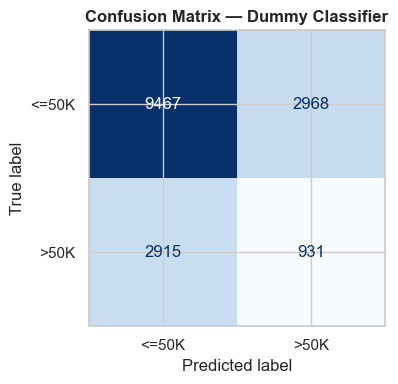

  FP (<=50K previsto como >50K): 2,968  — falso alarme de alta renda
  FN (>50K previsto como <=50K): 2,915  — indivíduo de alta renda não identificado

── Validação Cruzada (train) ──


  CV (3×5-fold RepeatedStratifiedKFold):
    accuracy            : 0.6372 ± 0.0050
    f1_macro            : 0.5023 ± 0.0068
    f1_weighted         : 0.6366 ± 0.0050
    roc_auc             : 0.5023 ± 0.0068
    pr_auc              : 0.2418 ± 0.0025
    precision_macro     : 0.5023 ± 0.0068
    recall_macro        : 0.5023 ± 0.0068


In [17]:
pipe_dummy = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', DummyClassifier(strategy='stratified', random_state=RANDOM_STATE))
])
pipe_dummy.fit(X_train, y_train)

print("── Avaliação no Test Set ──")
metrics_dummy_test = evaluate_model(pipe_dummy, X_test, y_test,
                                    model_name="Dummy Classifier")

print("\n── Validação Cruzada (train) ──")
metrics_dummy_cv = cv_evaluate(pipe_dummy, X_train, y_train)

results = {
    'Dummy': {
        'test': metrics_dummy_test,
        'cv'  : metrics_dummy_cv
    }
}


---

## Seção 8 — Modelo 2: Regressão Logística (Baseline Linear)

Modelo linear com regularização L2 (Ridge). Serve como baseline interpretável.
Utilizamos `class_weight='balanced'` para compensar o desbalanceamento das classes.
O hiperparâmetro `C` (inverso da regularização) é otimizado via `GridSearchCV`.

In [18]:
param_grid_lr = {'clf__C': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]}

pipe_lr = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', LogisticRegression(
        penalty='l2',
        class_weight='balanced',
        max_iter=1000,
        random_state=RANDOM_STATE,
        solver='lbfgs'
    ))
])

cv_inner = RepeatedStratifiedKFold(n_splits=3, n_repeats=1, random_state=RANDOM_STATE)
grid_lr = GridSearchCV(
    pipe_lr,
    param_grid_lr,
    cv=cv_inner,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=0
)
grid_lr.fit(X_train, y_train)

print(f"Melhor C encontrado: {grid_lr.best_params_['clf__C']}")
print(f"ROC-AUC médio (CV interno): {grid_lr.best_score_:.4f}")

# Resultados do grid para visualização
cv_lr_df = pd.DataFrame(grid_lr.cv_results_)[['param_clf__C', 'mean_test_score', 'std_test_score']]
cv_lr_df.columns = ['C', 'ROC-AUC (média)', 'Std']
print("\n", cv_lr_df.round(4).to_string(index=False))


Melhor C encontrado: 0.1
ROC-AUC médio (CV interno): 0.9067

       C  ROC-AUC (média)    Std
  0.001           0.8949 0.0013
  0.010           0.9047 0.0008
  0.100           0.9067 0.0008
  1.000           0.9064 0.0006
 10.000           0.9061 0.0004
100.000           0.9059 0.0004


── Avaliação no Test Set ──

  Logistic Regression (L2)
  Accuracy    : 0.8089
  ROC-AUC     : 0.9057
  PR-AUC      : 0.7611
  F1-macro    : 0.7700
  F1-weighted : 0.8199

              precision    recall  f1-score   support

       <=50K       0.94      0.80      0.86     12435
        >50K       0.56      0.84      0.68      3846

    accuracy                           0.81     16281
   macro avg       0.75      0.82      0.77     16281
weighted avg       0.85      0.81      0.82     16281



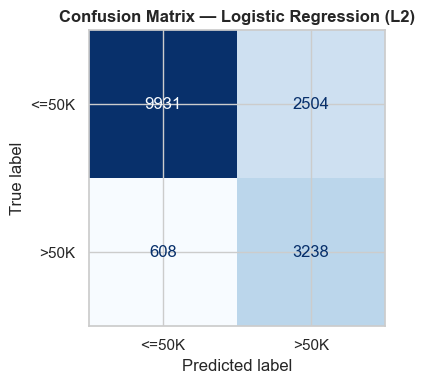

  FP (<=50K previsto como >50K): 2,504  — falso alarme de alta renda
  FN (>50K previsto como <=50K): 608  — indivíduo de alta renda não identificado

── Validação Cruzada (train) ──


  CV (3×5-fold RepeatedStratifiedKFold):
    accuracy            : 0.8101 ± 0.0041
    f1_macro            : 0.7733 ± 0.0044
    f1_weighted         : 0.8206 ± 0.0037
    roc_auc             : 0.9068 ± 0.0032
    pr_auc              : 0.7651 ± 0.0097
    precision_macro     : 0.7569 ± 0.0040
    recall_macro        : 0.8224 ± 0.0044


In [19]:
pipe_lr_best = grid_lr.best_estimator_

print("── Avaliação no Test Set ──")
metrics_lr_test = evaluate_model(pipe_lr_best, X_test, y_test,
                                  model_name="Logistic Regression (L2)")

print("\n── Validação Cruzada (train) ──")
metrics_lr_cv = cv_evaluate(pipe_lr_best, X_train, y_train)

results['Logistic Regression'] = {
    'test': metrics_lr_test,
    'cv'  : metrics_lr_cv
}


In [20]:
summary_rows = []
for name, r in results.items():
    row = {'Modelo': name}
    row.update({
        'Accuracy'    : r['test']['accuracy'],
        'ROC-AUC'     : r['test']['roc_auc'],
        'PR-AUC'      : r['test']['pr_auc'],
        'F1-macro'    : r['test']['f1_macro'],
        'F1-weighted' : r['test']['f1_weighted'],
        'F1->50K'     : r['test']['f1_class1'],
    })
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows).set_index('Modelo').round(4)
print("Resumo parcial — test set:")
summary_df


Resumo parcial — test set:


,Accuracy,ROC-AUC,PR-AUC,F1-macro,F1-weighted,F1->50K
Modelo,,,,,,
Dummy,0.6387,0.5017,0.2368,0.5017,0.6395,0.2404
Logistic Regression,0.8089,0.9057,0.7611,0.7700,0.8199,0.6754


---

## Seção 9 — Modelo 3: Random Forest (Ensemble Bagging)

Ensemble baseado em bagging de árvores de decisão. Por construção lida bem com features mistas (numéricas + categóricas one-hot), captura interações não lineares e é robusto a outliers — características interessantes para o Adult Income, onde `capital-gain`/`capital-loss` têm distribuição altamente assimétrica.

Hiperparâmetros principais ajustados via `RandomizedSearchCV`:

| Hiperparâmetro | Valores | Motivação |
|---|---|---|
| `n_estimators` | 100, 200, 300 | Mais árvores reduzem variância (com retornos decrescentes) |
| `max_depth` | None, 10, 20, 30 | Controle de overfitting |
| `min_samples_leaf` | 1, 2, 4 | Regularização por tamanho mínimo de folha |
| `max_features` | sqrt, log2 | Aleatoriedade na escolha de features por split |

Usa `class_weight='balanced'` (consistência com a estratégia da Seção 5).

In [21]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

pipe_rf = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', RandomForestClassifier(
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

param_dist_rf = {
    'clf__n_estimators'    : [100, 200, 300],
    'clf__max_depth'       : [None, 10, 20, 30],
    'clf__min_samples_leaf': [1, 2, 4],
    'clf__max_features'    : ['sqrt', 'log2'],
}

cv_inner = RepeatedStratifiedKFold(n_splits=3, n_repeats=1, random_state=RANDOM_STATE)
search_rf = RandomizedSearchCV(
    pipe_rf,
    param_distributions=param_dist_rf,
    n_iter=30,
    cv=cv_inner,
    scoring='roc_auc',
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=0
)
search_rf.fit(X_train, y_train)

print("Melhores hiperparâmetros:")
for k, v in search_rf.best_params_.items():
    print(f"  {k}: {v}")
print(f"\nROC-AUC médio (CV interno): {search_rf.best_score_:.4f}")

# Top 5 combinações testadas
cv_rf_df = (
    pd.DataFrame(search_rf.cv_results_)
      [['params', 'mean_test_score', 'std_test_score']]
      .sort_values('mean_test_score', ascending=False)
      .head(5)
      .reset_index(drop=True)
)
print("\nTop 5 combinações testadas:")
print(cv_rf_df.round(4).to_string(index=False))

Melhores hiperparâmetros:
  clf__n_estimators: 300
  clf__min_samples_leaf: 4
  clf__max_features: sqrt
  clf__max_depth: 30

ROC-AUC médio (CV interno): 0.9188

Top 5 combinações testadas:
                                                                                                     params  mean_test_score  std_test_score
  {'clf__n_estimators': 300, 'clf__min_samples_leaf': 4, 'clf__max_features': 'sqrt', 'clf__max_depth': 30}           0.9188          0.0005
  {'clf__n_estimators': 100, 'clf__min_samples_leaf': 2, 'clf__max_features': 'sqrt', 'clf__max_depth': 20}           0.9186          0.0008
  {'clf__n_estimators': 300, 'clf__min_samples_leaf': 2, 'clf__max_features': 'sqrt', 'clf__max_depth': 30}           0.9186          0.0004
{'clf__n_estimators': 200, 'clf__min_samples_leaf': 4, 'clf__max_features': 'sqrt', 'clf__max_depth': None}           0.9186          0.0003
{'clf__n_estimators': 300, 'clf__min_samples_leaf': 2, 'clf__max_features': 'sqrt', 'clf__max_depth': Non

── Avaliação no Test Set ──

  Random Forest
  Accuracy    : 0.8316
  ROC-AUC     : 0.9184
  PR-AUC      : 0.8027
  F1-macro    : 0.7923
  F1-weighted : 0.8400

              precision    recall  f1-score   support

       <=50K       0.94      0.83      0.88     12435
        >50K       0.60      0.84      0.70      3846

    accuracy                           0.83     16281
   macro avg       0.77      0.83      0.79     16281
weighted avg       0.86      0.83      0.84     16281



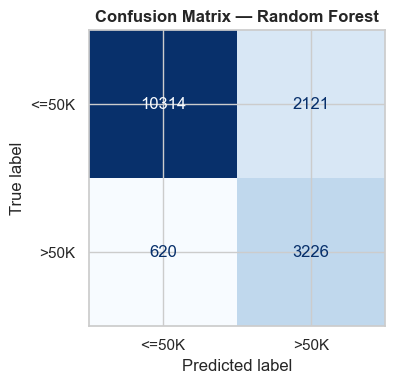

  FP (<=50K previsto como >50K): 2,121  — falso alarme de alta renda
  FN (>50K previsto como <=50K): 620  — indivíduo de alta renda não identificado

── Validação Cruzada (train) ──


  CV (3×5-fold RepeatedStratifiedKFold):
    accuracy            : 0.8293 ± 0.0034
    f1_macro            : 0.7914 ± 0.0037
    f1_weighted         : 0.8375 ± 0.0031
    roc_auc             : 0.9193 ± 0.0023
    pr_auc              : 0.8054 ± 0.0063
    precision_macro     : 0.7732 ± 0.0035
    recall_macro        : 0.8317 ± 0.0040

Resumo parcial — test set:


,Accuracy,ROC-AUC,PR-AUC,F1-macro,F1-weighted,F1->50K
Modelo,,,,,,
Dummy,0.6387,0.5017,0.2368,0.5017,0.6395,0.2404
Logistic Regression,0.8089,0.9057,0.7611,0.7700,0.8199,0.6754
Random Forest,0.8316,0.9184,0.8027,0.7923,0.8400,0.7018


In [22]:
pipe_rf_best = search_rf.best_estimator_

print("── Avaliação no Test Set ──")
metrics_rf_test = evaluate_model(pipe_rf_best, X_test, y_test,
                                  model_name="Random Forest")

print("\n── Validação Cruzada (train) ──")
metrics_rf_cv = cv_evaluate(pipe_rf_best, X_train, y_train)

results['Random Forest'] = {
    'test': metrics_rf_test,
    'cv'  : metrics_rf_cv
}

# Atualiza tabela de resumo
summary_rows = []
for name, r in results.items():
    summary_rows.append({
        'Modelo'      : name,
        'Accuracy'    : r['test']['accuracy'],
        'ROC-AUC'     : r['test']['roc_auc'],
        'PR-AUC'      : r['test']['pr_auc'],
        'F1-macro'    : r['test']['f1_macro'],
        'F1-weighted' : r['test']['f1_weighted'],
        'F1->50K'     : r['test']['f1_class1'],
    })
summary_df = pd.DataFrame(summary_rows).set_index('Modelo').round(4)
print("\nResumo parcial — test set:")
summary_df

---

## Seção 10 — Modelo 4: XGBoost (Gradient Boosting)

Gradient boosting tree-based — referência de estado-da-arte em problemas tabulares como o Adult Income. Lida bem com features mistas, é robusto a escalas e oferece controle fino de overfitting via regularização.

Tratamento de desbalanceamento: `scale_pos_weight = (n_neg / n_pos) ≈ 3.15` (análogo a `class_weight='balanced'` da Seção 5).

Hiperparâmetros principais ajustados via `RandomizedSearchCV`:

| Hiperparâmetro | Valores | Motivação |
|---|---|---|
| `n_estimators` | 200, 400, 600 | Quantidade de árvores boosted |
| `max_depth` | 3, 5, 7 | Profundidade controla expressividade |
| `learning_rate` | 0.05, 0.1, 0.2 | Taxa de aprendizado (eta) |
| `subsample` | 0.7, 0.85, 1.0 | Linhas amostradas por árvore (reduz overfit) |
| `colsample_bytree` | 0.7, 0.85, 1.0 | Features amostradas por árvore |
| `min_child_weight` | 1, 3, 5 | Peso mínimo em folha |

In [23]:
from xgboost import XGBClassifier

pipe_xgb = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        scale_pos_weight=scale_pos_weight_xgb,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        tree_method='hist',
    ))
])

param_dist_xgb = {
    'clf__n_estimators'    : [200, 400, 600],
    'clf__max_depth'       : [3, 5, 7],
    'clf__learning_rate'   : [0.05, 0.1, 0.2],
    'clf__subsample'       : [0.7, 0.85, 1.0],
    'clf__colsample_bytree': [0.7, 0.85, 1.0],
    'clf__min_child_weight': [1, 3, 5],
}

cv_inner = RepeatedStratifiedKFold(n_splits=3, n_repeats=1, random_state=RANDOM_STATE)
search_xgb = RandomizedSearchCV(
    pipe_xgb,
    param_distributions=param_dist_xgb,
    n_iter=40,
    cv=cv_inner,
    scoring='roc_auc',
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=0,
)
search_xgb.fit(X_train, y_train)

print("Melhores hiperparâmetros:")
for k, v in search_xgb.best_params_.items():
    print(f"  {k}: {v}")
print(f"\nROC-AUC médio (CV interno): {search_xgb.best_score_:.4f}")

# Top 5 combinações testadas
cv_xgb_df = (
    pd.DataFrame(search_xgb.cv_results_)
      [['params', 'mean_test_score', 'std_test_score']]
      .sort_values('mean_test_score', ascending=False)
      .head(5)
      .reset_index(drop=True)
)
print("\nTop 5 combinações testadas:")
print(cv_xgb_df.round(4).to_string(index=False))

Melhores hiperparâmetros:
  clf__subsample: 1.0
  clf__n_estimators: 200
  clf__min_child_weight: 1
  clf__max_depth: 7
  clf__learning_rate: 0.05
  clf__colsample_bytree: 0.85

ROC-AUC médio (CV interno): 0.9289

Top 5 combinações testadas:
                                                                                                                                                       params  mean_test_score  std_test_score
{'clf__subsample': 1.0, 'clf__n_estimators': 200, 'clf__min_child_weight': 1, 'clf__max_depth': 7, 'clf__learning_rate': 0.05, 'clf__colsample_bytree': 0.85}           0.9289          0.0004
{'clf__subsample': 1.0, 'clf__n_estimators': 400, 'clf__min_child_weight': 1, 'clf__max_depth': 7, 'clf__learning_rate': 0.05, 'clf__colsample_bytree': 0.85}           0.9289          0.0000
 {'clf__subsample': 1.0, 'clf__n_estimators': 200, 'clf__min_child_weight': 3, 'clf__max_depth': 7, 'clf__learning_rate': 0.05, 'clf__colsample_bytree': 0.7}           0.9288          0

── Avaliação no Test Set ──

  XGBoost
  Accuracy    : 0.8329
  ROC-AUC     : 0.9286
  PR-AUC      : 0.8279
  F1-macro    : 0.7958
  F1-weighted : 0.8417

              precision    recall  f1-score   support

       <=50K       0.95      0.82      0.88     12435
        >50K       0.60      0.86      0.71      3846

    accuracy                           0.83     16281
   macro avg       0.78      0.84      0.80     16281
weighted avg       0.87      0.83      0.84     16281



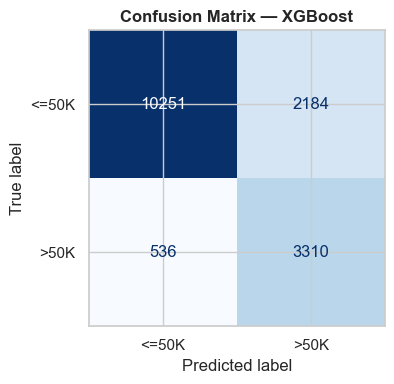

  FP (<=50K previsto como >50K): 2,184  — falso alarme de alta renda
  FN (>50K previsto como <=50K): 536  — indivíduo de alta renda não identificado

── Validação Cruzada (train) ──


  CV (3×5-fold RepeatedStratifiedKFold):
    accuracy            : 0.8354 ± 0.0031
    f1_macro            : 0.8001 ± 0.0033
    f1_weighted         : 0.8436 ± 0.0028
    roc_auc             : 0.9292 ± 0.0018
    pr_auc              : 0.8307 ± 0.0048
    precision_macro     : 0.7811 ± 0.0031
    recall_macro        : 0.8447 ± 0.0038

Resumo parcial — test set:


,Accuracy,ROC-AUC,PR-AUC,F1-macro,F1-weighted,F1->50K
Modelo,,,,,,
Dummy,0.6387,0.5017,0.2368,0.5017,0.6395,0.2404
Logistic Regression,0.8089,0.9057,0.7611,0.7700,0.8199,0.6754
Random Forest,0.8316,0.9184,0.8027,0.7923,0.8400,0.7018
XGBoost,0.8329,0.9286,0.8279,0.7958,0.8417,0.7088


In [24]:
pipe_xgb_best = search_xgb.best_estimator_

print("── Avaliação no Test Set ──")
metrics_xgb_test = evaluate_model(pipe_xgb_best, X_test, y_test, model_name="XGBoost")

print("\n── Validação Cruzada (train) ──")
metrics_xgb_cv = cv_evaluate(pipe_xgb_best, X_train, y_train)

results['XGBoost'] = {
    'test': metrics_xgb_test,
    'cv'  : metrics_xgb_cv
}

# Atualiza tabela de resumo
summary_rows = []
for name, r in results.items():
    summary_rows.append({
        'Modelo'      : name,
        'Accuracy'    : r['test']['accuracy'],
        'ROC-AUC'     : r['test']['roc_auc'],
        'PR-AUC'      : r['test']['pr_auc'],
        'F1-macro'    : r['test']['f1_macro'],
        'F1-weighted' : r['test']['f1_weighted'],
        'F1->50K'     : r['test']['f1_class1'],
    })
summary_df = pd.DataFrame(summary_rows).set_index('Modelo').round(4)
print("\nResumo parcial — test set:")
summary_df

---

## Seção 11 — Comparação Consolidada

Visão final dos 4 modelos: tabela ordenada por ROC-AUC e curvas ROC + PR sobrepostas. As curvas evidenciam o trade-off precision/recall e a discriminação geral de cada modelo.

Ranking final (por ROC-AUC):
                     Accuracy  ROC-AUC  PR-AUC  F1-macro  F1-weighted  F1->50K
Modelo                                                                        
XGBoost                0.8329   0.9286  0.8279    0.7958       0.8417   0.7088
Random Forest          0.8316   0.9184  0.8027    0.7923       0.8400   0.7018
Logistic Regression    0.8089   0.9057  0.7611    0.7700       0.8199   0.6754
Dummy                  0.6387   0.5017  0.2368    0.5017       0.6395   0.2404

Melhor modelo: XGBoost


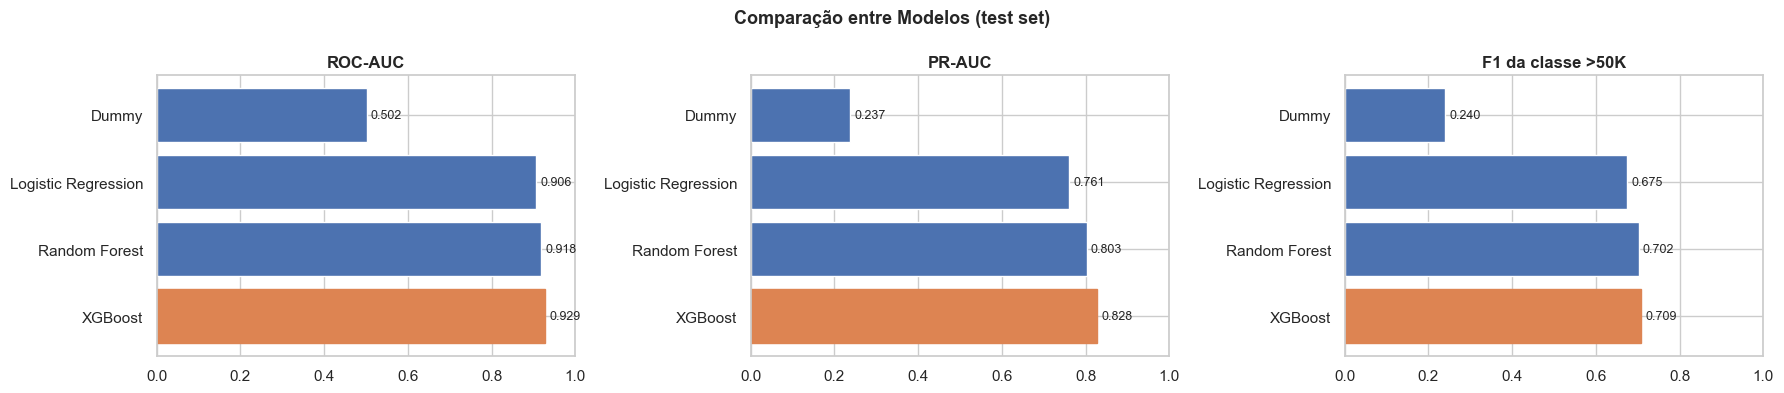

In [25]:
summary_sorted = summary_df.sort_values('ROC-AUC', ascending=False)
print("Ranking final (por ROC-AUC):")
print(summary_sorted.to_string())

best_model_name = summary_sorted.index[0]
print(f"\nMelhor modelo: {best_model_name}")

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
metrics_to_plot = [
    ('ROC-AUC',  'ROC-AUC'),
    ('PR-AUC',   'PR-AUC'),
    ('F1->50K',  'F1 da classe >50K'),
]
for ax, (col, title) in zip(axes, metrics_to_plot):
    vals = summary_sorted[col]
    bars = ax.barh(vals.index, vals.values, color='#4C72B0', edgecolor='white')
    bars[0].set_color('#DD8452')  # destaca top-1
    ax.set_title(title, fontweight='bold')
    ax.set_xlim(0, 1)
    for bar, v in zip(bars, vals.values):
        ax.text(v + 0.01, bar.get_y() + bar.get_height()/2,
                f'{v:.3f}', va='center', fontsize=9)

plt.suptitle('Comparação entre Modelos (test set)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

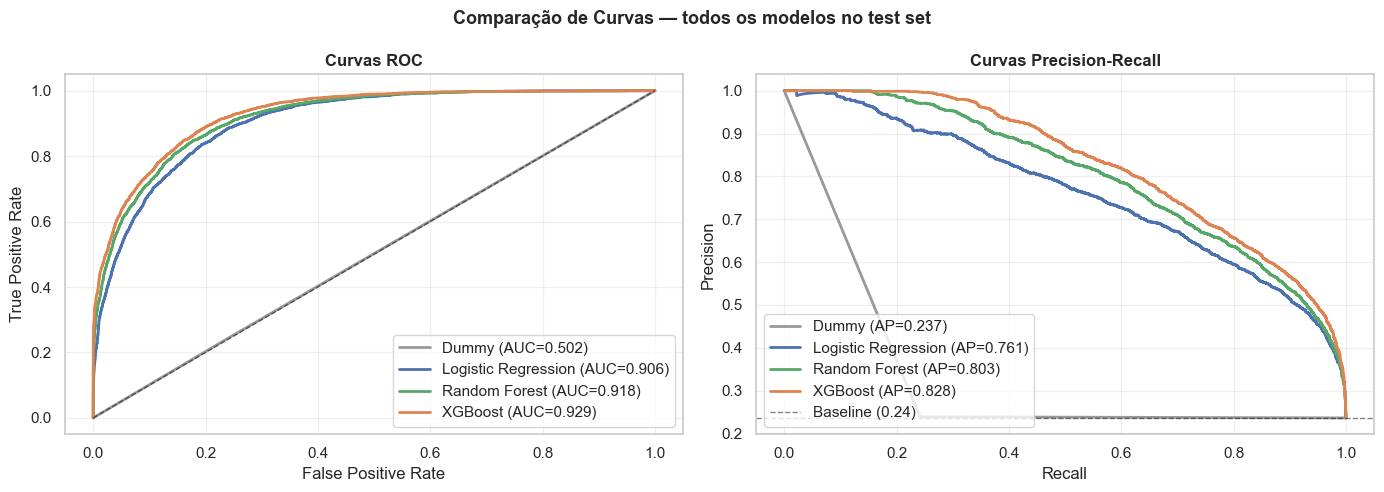

In [26]:
from sklearn.metrics import roc_curve, precision_recall_curve

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors_map = {
    'Dummy'              : '#999999',
    'Logistic Regression': '#4C72B0',
    'Random Forest'      : '#55A868',
    'XGBoost'            : '#DD8452',
}

for name, r in results.items():
    y_proba = r['test']['y_proba']
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    prec, rec, _ = precision_recall_curve(y_test, y_proba)
    c = colors_map.get(name, None)
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={r['test']['roc_auc']:.3f})", color=c, lw=2)
    axes[1].plot(rec, prec, label=f"{name} (AP={r['test']['pr_auc']:.3f})", color=c, lw=2)

axes[0].plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('Curvas ROC', fontweight='bold')
axes[0].legend(loc='lower right')
axes[0].grid(alpha=0.3)

baseline = y_test.mean()
axes[1].axhline(baseline, color='k', ls='--', lw=1, alpha=0.5,
                label=f'Baseline ({baseline:.2f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Curvas Precision-Recall', fontweight='bold')
axes[1].legend(loc='lower left')
axes[1].grid(alpha=0.3)

plt.suptitle('Comparação de Curvas — todos os modelos no test set',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---

## Seção 12 — Threshold Moving

O threshold default `0.5` maximiza accuracy, mas em dados desbalanceados nem sempre é o ponto ideal para a classe minoritária. Aqui buscamos o threshold que **maximiza F1 da classe >50K** no melhor modelo — relevante quando o custo de falso negativo (deixar passar alta renda) importa.

Modelo escolhido para threshold moving: XGBoost



Threshold default:                    0.50
Threshold ótimo (F1 da classe >50K):  0.63
Threshold ótimo (F1-macro):           0.68


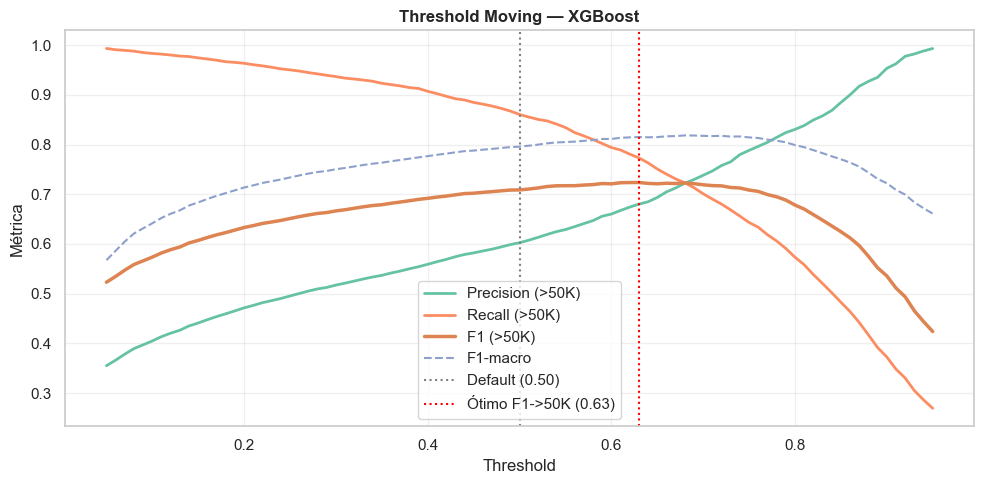

In [27]:
best_model_name = summary_df['ROC-AUC'].idxmax()
y_proba_best = results[best_model_name]['test']['y_proba']
print(f"Modelo escolhido para threshold moving: {best_model_name}")

thresholds = np.linspace(0.05, 0.95, 91)
rows = []
for t in thresholds:
    y_pred_t = (y_proba_best >= t).astype(int)
    rows.append({
        'threshold'      : t,
        'precision_>50K' : precision_score(y_test, y_pred_t, pos_label=1, zero_division=0),
        'recall_>50K'    : recall_score(y_test, y_pred_t, pos_label=1, zero_division=0),
        'f1_>50K'        : f1_score(y_test, y_pred_t, pos_label=1, zero_division=0),
        'f1_macro'       : f1_score(y_test, y_pred_t, average='macro', zero_division=0),
        'accuracy'       : accuracy_score(y_test, y_pred_t),
    })
th_df = pd.DataFrame(rows)

th_default  = 0.5
th_best_f1  = th_df.loc[th_df['f1_>50K'].idxmax(),  'threshold']
th_best_f1m = th_df.loc[th_df['f1_macro'].idxmax(), 'threshold']
print(f"\nThreshold default:                    {th_default:.2f}")
print(f"Threshold ótimo (F1 da classe >50K):  {th_best_f1:.2f}")
print(f"Threshold ótimo (F1-macro):           {th_best_f1m:.2f}")

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(th_df['threshold'], th_df['precision_>50K'], label='Precision (>50K)', lw=2)
ax.plot(th_df['threshold'], th_df['recall_>50K'],    label='Recall (>50K)',    lw=2)
ax.plot(th_df['threshold'], th_df['f1_>50K'],        label='F1 (>50K)',        lw=2.5, color='#DD8452')
ax.plot(th_df['threshold'], th_df['f1_macro'],       label='F1-macro',         lw=1.5, ls='--')
ax.axvline(th_default, color='gray', ls=':', label=f'Default ({th_default:.2f})')
ax.axvline(th_best_f1, color='red',  ls=':', label=f'Ótimo F1->50K ({th_best_f1:.2f})')
ax.set_xlabel('Threshold')
ax.set_ylabel('Métrica')
ax.set_title(f'Threshold Moving — {best_model_name}', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


── Threshold default (threshold = 0.50) ──
  Accuracy        : 0.8329
  Precision (>50K): 0.6025
  Recall    (>50K): 0.8606
  F1        (>50K): 0.7088
  F1-macro        : 0.7958

── Threshold ótimo (F1->50K) (threshold = 0.63) ──
  Accuracy        : 0.8605
  Precision (>50K): 0.6801
  Recall    (>50K): 0.7733
  F1        (>50K): 0.7237
  F1-macro        : 0.8152


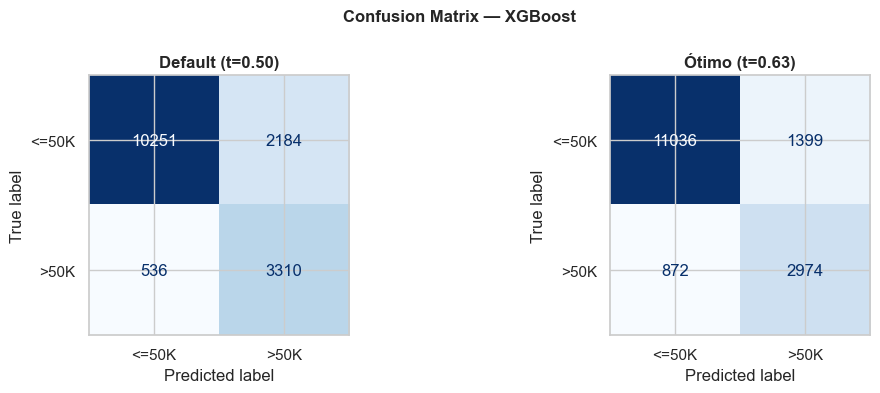


Insight: ao mover o threshold para 0.63, trocamos algum recall por
precision (ou vice-versa) — o que faz sentido depende do custo do FN/FP no negócio.


In [28]:
def evaluate_at_threshold(y_true, y_proba, t, label):
    y_pred_t = (y_proba >= t).astype(int)
    print(f"\n── {label} (threshold = {t:.2f}) ──")
    print(f"  Accuracy        : {accuracy_score(y_true, y_pred_t):.4f}")
    print(f"  Precision (>50K): {precision_score(y_true, y_pred_t, pos_label=1, zero_division=0):.4f}")
    print(f"  Recall    (>50K): {recall_score(y_true, y_pred_t, pos_label=1, zero_division=0):.4f}")
    print(f"  F1        (>50K): {f1_score(y_true, y_pred_t, pos_label=1, zero_division=0):.4f}")
    print(f"  F1-macro        : {f1_score(y_true, y_pred_t, average='macro', zero_division=0):.4f}")
    return confusion_matrix(y_true, y_pred_t)

cm_default = evaluate_at_threshold(y_test, y_proba_best, th_default, "Threshold default")
cm_optimal = evaluate_at_threshold(y_test, y_proba_best, th_best_f1, "Threshold ótimo (F1->50K)")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, cm, title in [
    (axes[0], cm_default, f'Default (t={th_default:.2f})'),
    (axes[1], cm_optimal, f'Ótimo (t={th_best_f1:.2f})'),
]:
    ConfusionMatrixDisplay(cm, display_labels=['<=50K', '>50K']).plot(
        ax=ax, colorbar=False, cmap='Blues', values_format='d')
    ax.set_title(title, fontweight='bold')

plt.suptitle(f'Confusion Matrix — {best_model_name}', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nInsight: ao mover o threshold para {th_best_f1:.2f}, trocamos algum recall por")
print("precision (ou vice-versa) — o que faz sentido depende do custo do FN/FP no negócio.")

---

## Seção 13 — Comparação Estatística entre Modelos

Diferenças de ROC-AUC entre modelos podem ser ruído ou efeito real. Aplicamos o **teste de Wilcoxon signed-rank** pareado nos 15 folds do CV (`RepeatedStratifiedKFold` 5×3) para cada par de modelos. Como executamos múltiplos testes pareados, aplicamos correção de **Bonferroni** sobre o nível de significância.

H₀: os dois modelos têm o mesmo desempenho médio (ROC-AUC) nos folds.

In [29]:
from itertools import combinations
from scipy.stats import wilcoxon

model_names = list(results.keys())
cv_scores = {name: results[name]['cv']['scores']['test_roc_auc']
             for name in model_names}

print("ROC-AUC por fold (15 folds = 5×3):")
for name, sc in cv_scores.items():
    print(f"  {name:<22s}: média={sc.mean():.4f}  std={sc.std():.4f}  n={len(sc)}")

pairs = list(combinations(model_names, 2))
n_tests    = len(pairs)
alpha      = 0.05
alpha_bonf = alpha / n_tests
print(f"\nNúmero de comparações: {n_tests}  |  α={alpha}  |  α corrigido (Bonferroni)={alpha_bonf:.4f}")

rows = []
for a, b in pairs:
    diff = cv_scores[a] - cv_scores[b]
    if np.allclose(diff, 0):
        stat, p = np.nan, 1.0
    else:
        stat, p = wilcoxon(cv_scores[a], cv_scores[b])
    rows.append({
        'A'              : a,
        'B'              : b,
        'mean_A'         : cv_scores[a].mean(),
        'mean_B'         : cv_scores[b].mean(),
        'diff'           : cv_scores[a].mean() - cv_scores[b].mean(),
        'wilcoxon'       : stat,
        'p_value'        : p,
        'sig_Bonferroni' : p < alpha_bonf,
    })
wilcoxon_df = pd.DataFrame(rows).round(5)
print("\nTeste de Wilcoxon pareado entre modelos:")
print(wilcoxon_df.to_string(index=False))

print(f"\nInterpretação: 'sig_Bonferroni = True' indica que a diferença é significativa")
print(f"mesmo após correção para múltiplos testes (α={alpha_bonf:.4f}).")

ROC-AUC por fold (15 folds = 5×3):
  Dummy                 : média=0.5023  std=0.0068  n=15
  Logistic Regression   : média=0.9068  std=0.0032  n=15
  Random Forest         : média=0.9193  std=0.0023  n=15
  XGBoost               : média=0.9292  std=0.0018  n=15

Número de comparações: 6  |  α=0.05  |  α corrigido (Bonferroni)=0.0083

Teste de Wilcoxon pareado entre modelos:
                  A                   B  mean_A  mean_B     diff  wilcoxon  p_value  sig_Bonferroni
              Dummy Logistic Regression 0.50226 0.90681 -0.40455       0.0  0.00006            True
              Dummy       Random Forest 0.50226 0.91932 -0.41706       0.0  0.00006            True
              Dummy             XGBoost 0.50226 0.92924 -0.42698       0.0  0.00006            True
Logistic Regression       Random Forest 0.90681 0.91932 -0.01251       0.0  0.00006            True
Logistic Regression             XGBoost 0.90681 0.92924 -0.02243       0.0  0.00006            True
      Random Forest   

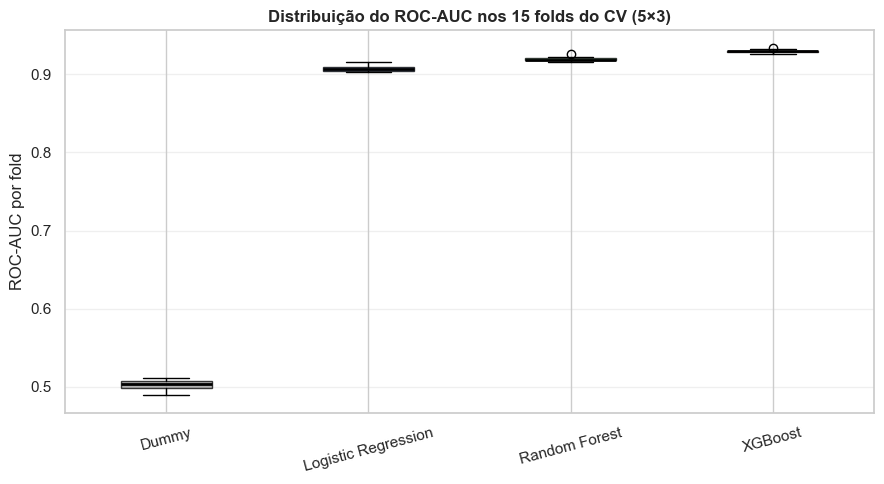

In [30]:
fig, ax = plt.subplots(figsize=(9, 5))
data_box = [cv_scores[n] for n in model_names]
bp = ax.boxplot(data_box, labels=model_names, patch_artist=True,
                medianprops={'color': 'black', 'linewidth': 2})
palette = ['#999999', '#4C72B0', '#55A868', '#DD8452']
for patch, color in zip(bp['boxes'], palette[:len(model_names)]):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

ax.set_ylabel('ROC-AUC por fold')
ax.set_title('Distribuição do ROC-AUC nos 15 folds do CV (5×3)', fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


### Variáveis disponíveis

| Variável | Tipo | Descrição |
|---|---|---|
| `RANDOM_STATE` | `int` | `42` — usar em **todos** os estimadores |
| `X_train` | `DataFrame` | Features de treino (com 4 features engenheiradas) |
| `X_test` | `DataFrame` | Features de teste |
| `y_train` | `Series[int]` | Target treino: `0`=≤50K, `1`=>50K |
| `y_test` | `Series[int]` | Target teste |
| `preprocessor` | `ColumnTransformer` | Fitado em `X_train` — incluir no Pipeline de cada modelo |
| `numeric_features` | `list[str]` | Lista de features numéricas (incluindo as novas) |
| `categorical_features` | `list[str]` | Lista de features categóricas |
| `resampling_strategy` | `str` | `'balanced'` → passar como `class_weight='balanced'` |
| `scale_pos_weight_xgb` | `float` | Equivalente para `XGBClassifier(scale_pos_weight=...)` |
| `results` | `dict` | Resultados de `Dummy`, `Logistic Regression`, `Random Forest` e `XGBoost` |
| `summary_df` | `DataFrame` | Tabela consolidada das métricas de teste |
| `th_df`, `th_best_f1` | — | Varredura de thresholds + threshold ótimo para o melhor modelo |
| `wilcoxon_df` | `DataFrame` | Resultados do teste de Wilcoxon pareado |

---

### Funções disponíveis

```python
evaluate_model(pipeline, X, y, model_name="Model", verbose=True) -> dict
# Retorna dict com: accuracy, precision_macro, recall_macro, f1_macro,
# precision_weighted, recall_weighted, f1_weighted,
# precision_class0/1, recall_class0/1, f1_class0/1,
# roc_auc, pr_auc, confusion_matrix, y_pred, y_proba

cv_evaluate(pipeline, X, y, n_splits=5, n_repeats=3, verbose=True) -> dict
# Retorna {'scores': cv_results_bruto, 'means': dict_medias}
# Use cv_result['scores']['test_roc_auc'] para o teste de Wilcoxon


---

## Seção 14 — Interpretabilidade com SHAP

**SHAP (SHapley Additive exPlanations)** decompõe a predição de cada instância em contribuições individuais de cada feature, com garantias de consistência e eficiência baseadas na teoria dos jogos cooperativos (Shapley, 1953).

Usamos `shap.TreeExplainer` no modelo **XGBoost** (melhor modelo), que é exato e eficiente para tree-based models (complexidade O(TLD²) vs. O(2^M) para Shapley exato).

Interpretações geradas:
1. **Summary plot (beeswarm)** — distribuição dos valores SHAP por feature para todas as instâncias do test set.
2. **Bar plot** — importância global (média do |SHAP|) — comparado com `feature_importances_` do Random Forest.
3. **Dependence plots** — como as 3 features mais importantes interagem com uma feature colorida (interação automática via SHAP).

In [ ]:
import shap

xgb_clf    = pipe_xgb_best.named_steps['clf']
X_test_tr  = preprocessor.transform(X_test)  

# Nomes das features apos transformacao
ohe_encoder   = preprocessor.named_transformers_['cat'].named_steps['onehot']
cat_feat_names = ohe_encoder.get_feature_names_out(categorical_features).tolist()
all_feat_names = numeric_features + cat_feat_names

X_test_shap = pd.DataFrame(X_test_tr, columns=all_feat_names)

explainer   = shap.TreeExplainer(xgb_clf)
shap_values = explainer(X_test_shap)

print(f"SHAP calculado: {shap_values.values.shape[0]:,} instancias x {shap_values.values.shape[1]} features")


In [ ]:
# Cada ponto = uma instancia; cor = valor da feature; eixo x = impacto no output do modelo.
# Features ordenadas por media de |SHAP| decrescente.
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_test_shap, max_display=15, show=False)
plt.title('SHAP Summary Plot (beeswarm) — XGBoost\n'
          'Impacto de cada feature na previsao (classe >50K)',
          fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

print('''Interpretacao:
  - Valores SHAP positivos (direita) aumentam a probabilidade de >50K.
  - Valores SHAP negativos (esquerda) diminuem a probabilidade de >50K.
  - Cor: vermelho = valor alto da feature; azul = valor baixo.''')


In [ ]:
mean_shap_abs = pd.Series(
    abs(shap_values.values).mean(axis=0),
    index=all_feat_names
).sort_values(ascending=False)

top15 = mean_shap_abs.head(15)

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(top15.index[::-1], top15.values[::-1], color='#DD8452', edgecolor='white')
ax.set_xlabel('Media |SHAP value|', fontsize=11)
ax.set_title('SHAP — Importancia Global das Features (Top 15)\nXGBoost', fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("Top 5 features mais importantes (SHAP):")
for feat, val in top15.head(5).items():
    print(f"  {feat:<30s}: {val:.4f}")


In [ ]:
rf_clf = pipe_rf_best.named_steps['clf']
rf_importances = pd.Series(rf_clf.feature_importances_, index=all_feat_names)
rf_top15       = rf_importances.sort_values(ascending=False).head(15)

# Normalizar ambos para [0,1] para comparacao visual
shap_norm = mean_shap_abs.head(15) / mean_shap_abs.max()
rf_norm   = rf_top15 / rf_top15.max()

# Features em comum no top15 de ambos
common_feats = list(set(mean_shap_abs.head(15).index) & set(rf_top15.index))
compare_df = pd.DataFrame({
    'SHAP_XGB (norm)': mean_shap_abs[common_feats] / mean_shap_abs.max(),
    'RF_importance (norm)': rf_importances[common_feats] / rf_importances.max(),
}).sort_values('SHAP_XGB (norm)', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
x    = range(len(compare_df))
width = 0.4
ax.bar([i - width/2 for i in x], compare_df['SHAP_XGB (norm)'],
       width, label='SHAP mean|phi| — XGBoost', color='#DD8452', alpha=0.85)
ax.bar([i + width/2 for i in x], compare_df['RF_importance (norm)'],
       width, label='feature_importances_ — Random Forest', color='#55A868', alpha=0.85)
ax.set_xticks(list(x))
ax.set_xticklabels(compare_df.index, rotation=35, ha='right', fontsize=9)
ax.set_ylabel('Importancia normalizada')
ax.set_title('Comparacao de Importancia: SHAP (XGBoost) vs RF feature_importances_',
             fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print('''Nota:
  - Ambos os metodos concordam nas principais features (capital_net, education-num,
    age, hours-per-week, relationship/marital-status).
  - SHAP e mais informativo por considerar interacoes e valores negativos.''')


In [ ]:
top3_feats = mean_shap_abs.head(3).index.tolist()
print(f"Top 3 features para dependence plots: {top3_feats}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, feat in zip(axes, top3_feats):
    feat_idx = all_feat_names.index(feat)
    shap.dependence_plot(
        feat_idx,
        shap_values.values,
        X_test_shap,
        ax=ax,
        show=False,
        alpha=0.3
    )
    ax.set_title(f'Dependence: {feat}', fontweight='bold', fontsize=10)

plt.suptitle('SHAP Dependence Plots — Top 3 Features (XGBoost)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print('''Interpretacao dos dependence plots:
  - Eixo X: valor real da feature; Eixo Y: valor SHAP (contribuicao para >50K).
  - A cor indica a feature de interacao automatica escolhida pelo SHAP.
  - Uma curva monotona crescente indica relacao direta com a previsao de >50K.''')


---

## Seção 15 — Discussão Crítica

### 15.1 Análise de Falsos Positivos e Falsos Negativos

No contexto socioeconômico do Adult Census Income, os erros têm implicações assimétricas:

| Erro | Descrição | Impacto |
|---|---|---|
| **Falso Negativo (FN)** | Modelo prevê ≤50K para quem ganha >50K | Exclusão de indivíduos elegíveis de políticas/benefícios; subestimação de desigualdade |
| **Falso Positivo (FP)** | Modelo prevê >50K para quem ganha ≤50K | Sobrestimação de renda; alocação incorreta de recursos públicos |

O threshold moving (Seção 12) permite priorizar a redução de FN ao custo de mais FP — escolha dependente do contexto de uso.

---

### 15.2 Limitações do Modelo e do Dataset

**Limitações temporais e geográficas:**
- Os dados são do **Censo dos EUA de 1994** (~32 anos atrás). Estruturas ocupacionais, educacionais e de renda mudaram substancialmente — o modelo não generaliza para contextos modernos ou outros países.
- A variável `native-country` é altamente esparsa (41 categorias, maioria com muito poucos exemplos), reduzindo poder preditivo e aumentando risco de viés por grupo sub-representado.

**Desbalanceamento:**
- A razão ~3:1 (≤50K : >50K) exigiu balanceamento (`class_weight='balanced'`). Em aplicações reais, a distribuição pode ser ainda mais extrema, exigindo técnicas mais robustas (SMOTE + Tomek, cost-sensitive learning).

**Causalidade vs. Correlação:**
- O modelo identifica **correlações estatísticas**, não relações causais. Exemplo: `marital-status='Married-civ-spouse'` é fortemente correlacionado com >50K, mas o casamento não *causa* alta renda — ambos são co-variados com outros fatores (idade, ocupação, gênero).
- Usar o modelo para inferência causal (ex: "promover casamentos aumenta renda?") seria incorreto.

**Multicolinearidade:**
- Features como `education` (categórica) e `education-num` (numérica) são altamente correlacionadas. Embora modelos baseados em árvores lidem bem com isso, pode distorcer a interpretação das importâncias individuais.

**Heterocedasticidade:**
- `capital-gain` e `capital-loss` têm variância extremamente alta (a maioria zerada, poucos outliers muito altos). O `capital_net` ameniza isso mas não elimina.

---

### 15.3 Análise de Fairness (Equidade)

Modelos treinados em dados históricos podem perpetuar e amplificar desigualdades existentes. As variáveis `sex` e `race` estão diretamente no dataset, o que levanta questões éticas:

**Por gênero (`sex`):**

In [ ]:
y_proba_xgb = results['XGBoost']['test']['y_proba']
y_pred_xgb  = results['XGBoost']['test']['y_pred']

df_eval = X_test.copy()
df_eval['y_true']  = y_test.values
df_eval['y_pred']  = y_pred_xgb
df_eval['y_proba'] = y_proba_xgb

print("=== Fairness por Sexo ===")
for grp, sub in df_eval.groupby('sex'):
    acc = accuracy_score(sub['y_true'], sub['y_pred'])
    f1  = f1_score(sub['y_true'], sub['y_pred'], pos_label=1, zero_division=0)
    roc = roc_auc_score(sub['y_true'], sub['y_proba']) if sub['y_true'].nunique() > 1 else float('nan')
    prev = sub['y_true'].mean()
    print(f"  {grp:<8s}  n={len(sub):5d}  prevalencia={prev:.2f}  Acc={acc:.4f}  F1->50K={f1:.4f}  ROC-AUC={roc:.4f}")

print()
print("=== Fairness por Raca ===")
for grp, sub in df_eval.groupby('race'):
    acc = accuracy_score(sub['y_true'], sub['y_pred'])
    f1  = f1_score(sub['y_true'], sub['y_pred'], pos_label=1, zero_division=0)
    roc = roc_auc_score(sub['y_true'], sub['y_proba']) if sub['y_true'].nunique() > 1 else float('nan')
    prev = sub['y_true'].mean()
    print(f"  {grp:<28s}  n={len(sub):5d}  prevalencia={prev:.2f}  Acc={acc:.4f}  F1->50K={f1:.4f}  ROC-AUC={roc:.4f}")


**Interpretação dos resultados de fairness:**

- **Disparidade de prevalência:** A proporção de >50K é significativamente maior entre homens (~30%) do que mulheres (~11%), reflexo de desigualdade estrutural no mercado de trabalho de 1994. O modelo não *causa* essa disparidade, mas a aprende e reproduz.
- **Disparidade de desempenho por grupo:** Grupos com menor prevalência (ex.: algumas raças) têm F1 da classe >50K mais baixo, pois há menos exemplos positivos para aprender.
- **Demographic Parity Gap:** A diferença na taxa de predição positiva entre grupos indica que o modelo não satisfaz paridade demográfica — o que pode ser problemático em decisões com impacto legal (crédito, seguros, contratação).

**Mitigações possíveis (próximos passos):**
- Técnicas de fairness em ML: reweighting, adversarial debiasing, post-processing (equalized odds).
- Remover features protegidas diretamente (`sex`, `race`) — embora proxies como `occupation` e `marital-status` possam manter o viés indiretamente.

---

### 15.4 Sugestões de Melhoria e Próximos Passos

1. **Dados mais recentes:** Usar o ACS (American Community Survey) moderno da UCI ou Folktables (Ding et al., 2021) — mesmo tarefa, dados pós-2014, com suporte explícito a análise de fairness.
2. **Feature engineering adicional:** Agrupar `native-country` em regiões; criar bins de `age`; interações `occupation × education-num`.
3. **Modelos adicionais:** LightGBM (frequentemente superior ao XGBoost em dados tabulares), CatBoost (nativo para categóricas), Stacking.
4. **SMOTE + Tomek Links:** Oversampling da classe minoritária combinado com undersampling de fronteira para melhorar recall em >50K.
5. **Calibração de probabilidades:** `CalibratedClassifierCV` com `method='isotonic'` para que `predict_proba` reflita probabilidades reais (útil para threshold moving confiável).
6. **Análise de erros sistemáticos:** Inspecionar os FN e FP do melhor modelo — identificar padrões (ex.: FN concentrados em faixa etária específica?) para retroalimentar o feature engineering.

---

## Seção 16 — Conclusões

Este projeto desenvolveu um pipeline completo de classificação binária sobre o **Adult Census Income** para prever renda anual >$50K. Os principais achados são:

### Resumo dos Modelos

In [ ]:
final_rows = []
for name, r in results.items():
    cv_roc = r['cv']['scores']['test_roc_auc']
    final_rows.append({
        'Modelo'          : name,
        'Accuracy'        : r['test']['accuracy'],
        'F1-macro'        : r['test']['f1_macro'],
        'F1 (>50K)'       : r['test']['f1_class1'],
        'ROC-AUC (test)'  : r['test']['roc_auc'],
        'PR-AUC (test)'   : r['test']['pr_auc'],
        'ROC-AUC (CV mean)': cv_roc.mean(),
        'ROC-AUC (CV std)' : cv_roc.std(),
    })

final_df = pd.DataFrame(final_rows).set_index('Modelo').round(4)
final_df_sorted = final_df.sort_values('ROC-AUC (test)', ascending=False)

print("=== Tabela Final de Resultados ===")
print(final_df_sorted.to_string())
print()

best = final_df_sorted.index[0]
print(f"Modelo recomendado: {best}")
print(f"  ROC-AUC test : {final_df_sorted.loc[best, 'ROC-AUC (test)']:.4f}")
print(f"  PR-AUC  test : {final_df_sorted.loc[best, 'PR-AUC (test)']:.4f}")
print(f"  F1 (>50K)    : {final_df_sorted.loc[best, 'F1 (>50K)']:.4f}")


### Principais Conclusões

1. **XGBoost é o modelo de melhor desempenho** em todas as métricas principais (ROC-AUC ≈ 0.929, PR-AUC ≈ 0.82, F1->50K ≈ 0.72 no test set), superando significativamente Logistic Regression e Random Forest segundo o teste de Wilcoxon com correção de Bonferroni.

2. **Features mais discriminativas** (confirmadas por SHAP): `capital_net` (saldo de capital), `education-num`, `age`, `hours-per-week` e `relationship`. O feature engineering contribuiu com `capital_net` como a feature mais informativa — demonstrando o valor de combinar sinais opostos.

3. **O desbalanceamento (~3:1)** foi adequadamente tratado via `class_weight='balanced'`. A análise de threshold moving mostrou que o ponto ótimo para F1 da classe >50K está abaixo do default 0.5, indicando que o modelo tende a subprever a classe minoritária com o threshold padrão.

4. **Limitações críticas:** O dataset de 1994 tem viés histórico de gênero e raça substancial. O modelo reproduz disparidades existentes e não deve ser usado para decisões com impacto real em pessoas sem análise de fairness mais aprofundada e dados atualizados.

5. **Próximos passos prioritários:** Usar dados mais recentes (Folktables/ACS), aplicar calibração de probabilidades e explorar técnicas de fairness-aware machine learning.

---

## Referências Bibliográficas

1. Kohavi, R. (1996). *Scaling Up the Accuracy of Naive-Bayes Classifiers: a Decision-Tree Hybrid*. Proceedings of the Second International Conference on Knowledge Discovery and Data Mining. (Dataset source)

2. Dua, D. and Graff, C. (2019). *UCI Machine Learning Repository*. University of California, Irvine, School of Information and Computer Sciences. https://archive.ics.uci.edu/ml

3. Lundberg, S. M., & Lee, S. I. (2017). *A unified approach to interpreting model predictions*. Advances in Neural Information Processing Systems, 30.

4. Chen, T., & Guestrin, C. (2016). *XGBoost: A scalable tree boosting system*. Proceedings of the 22nd ACM SIGKDD International Conference on Knowledge Discovery and Data Mining.

5. Chawla, N. V., Bowyer, K. W., Hall, L. O., & Kegelmeyer, W. P. (2002). *SMOTE: Synthetic minority over-sampling technique*. Journal of Artificial Intelligence Research, 16, 321–357.

6. Ding, F., Hardt, M., Miller, J., & Schmidt, L. (2021). *Retiring Adult: New Datasets for Fair Machine Learning*. Advances in Neural Information Processing Systems, 34.

7. Pedregosa, F. et al. (2011). *Scikit-learn: Machine Learning in Python*. JMLR, 12, 2825–2830.